In [ ]:
import pandas as pd
#加载数据集
data = pd.read_csv('电子游戏销量数据集.csv')
data.head(), data.columns

(   Rank                      Name Platform    Year         Genre Publisher  \
 0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
 1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
 2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
 3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
 4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   
 
    NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
 0     41.49     29.02      3.77         8.46         82.74  
 1     29.08      3.58      6.81         0.77         40.24  
 2     15.85     12.88      3.79         3.31         35.82  
 3     15.75     11.01      3.28         2.96         33.00  
 4     11.27      8.89     10.22         1.00         31.37  ,
 Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
        'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
       dt

In [ ]:
import pandas as pd
file_path = '电子游戏销量数据集.csv'
data = pd.read_csv(file_path)
data.head()
# 检查缺失值情况
missing_data = data.isnull().sum()
missing_data
# 处理'Publisher'列的缺失值，填充为'Unknown'
data['Publisher'].fillna('Unknown', inplace=True)
# 根据已有非缺失的'Year'数据构建字典用于填充缺失的'Year'值
year_inference = data.dropna(subset=['Year']).set_index('Name')['Year'].to_dict()
data['Year'] = data.apply(lambda row: year_inference.get(row['Name'], row['Year']), axis=1)
# 再次检查'Year'列剩余的缺失值数量
remaining_missing_years = data['Year'].isnull().sum()
remaining_missing_years
# 用中位数填充剩余的缺失'Year'值
median_year = data['Year'].median()
data['Year'].fillna(median_year, inplace=True)
# 检查填充后'Year'列的缺失值数量，并输出中位数
remaining_missing_years_after_filling = data['Year'].isnull().sum()
remaining_missing_years_after_filling, median_year
# 添加代码：删除'Year'为2020和2017的数据
data = data[~((data['Year'] == 2020) | (data['Year'] == 2017))]
# 将清洗后的数据保存为新的CSV文件
data.to_csv('清洗后的电子游戏销量数据集.csv', index=False)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14800\167284839.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Publisher'].fillna('Unknown', inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14800\167284839.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

<Figure size 1400x700 with 0 Axes>

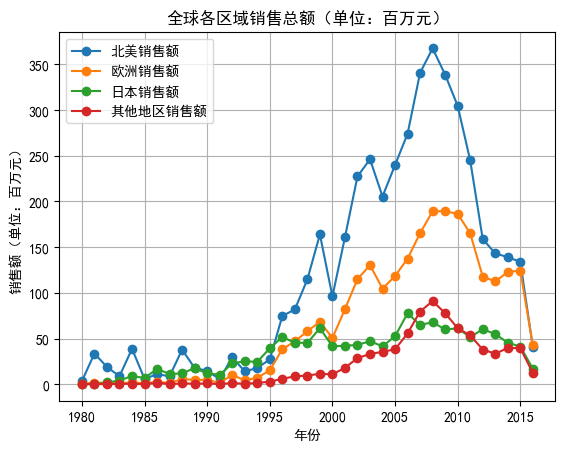

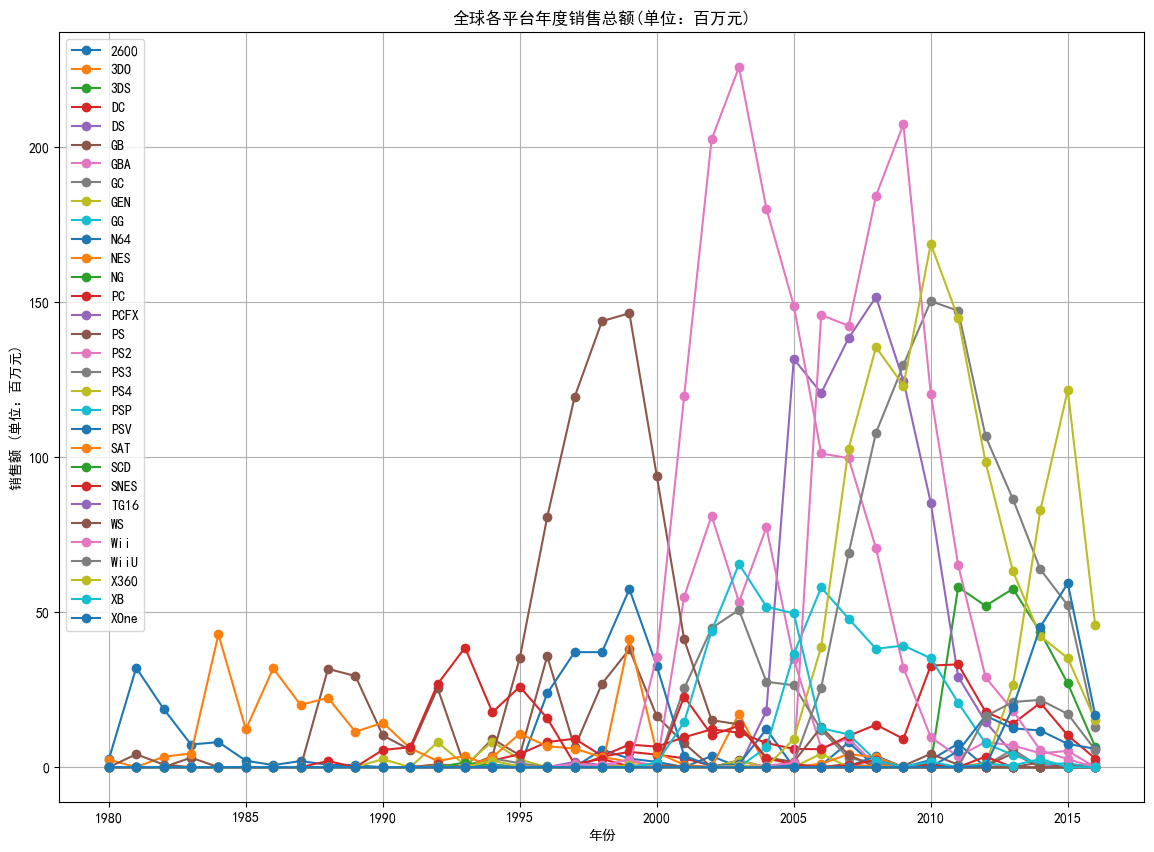

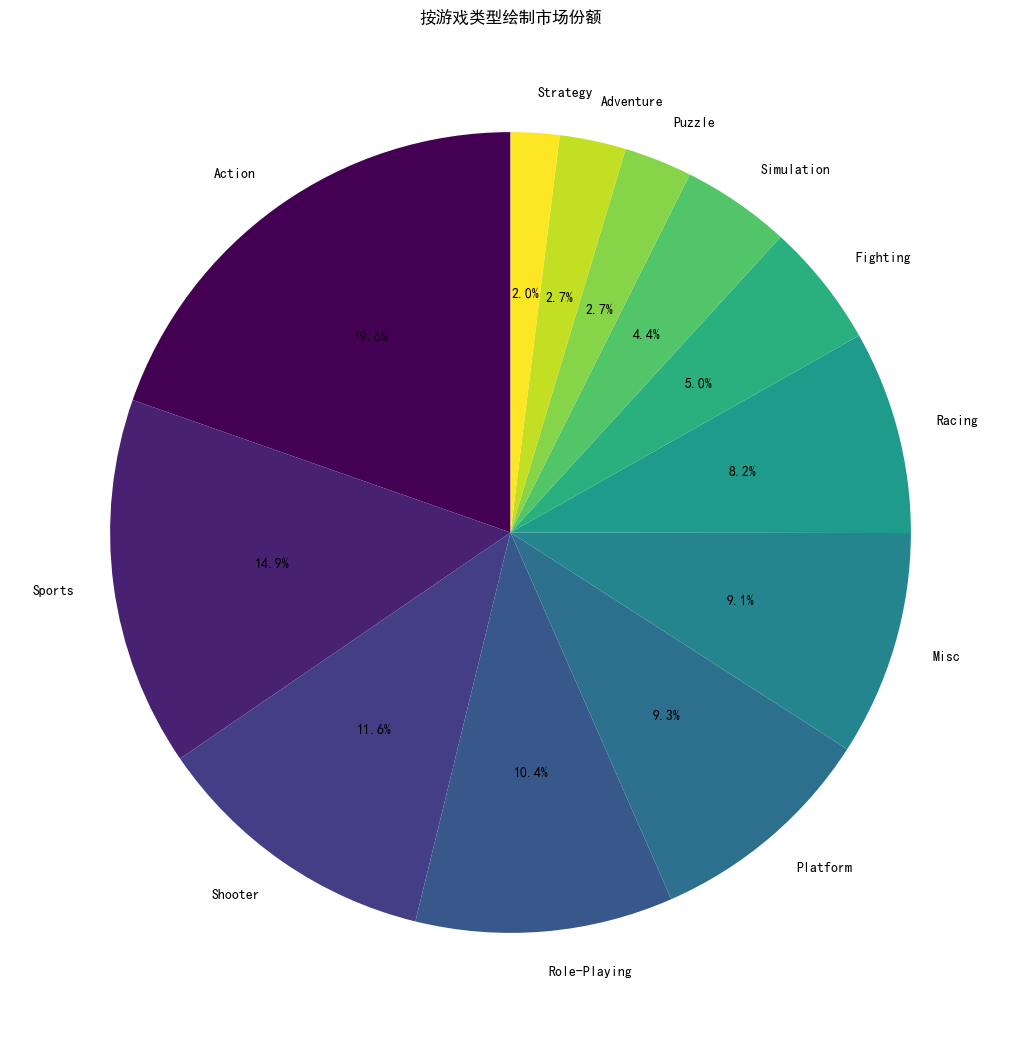

In [ ]:
#数据可视化
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('清洗后的电子游戏销量数据集.csv')

#全球各区域年度销售总额
yearly_region_sales = data.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(14, 7))
yearly_region_sales.plot(title='全球各区域销售总额（单位：百万元）', marker='o')
plt.rcParams['font.family'] = 'SimHei'
plt.xlabel('年份')
plt.ylabel('销售额（单位：百万元）')
plt.grid(True)
plt.legend(['北美销售额', '欧洲销售额', '日本销售额', '其他地区销售额'])
plt.rcParams['axes.unicode_minus'] = False
plt.show()

#全球各平台年度销售总额

platform_sales_trend = data.groupby(['Year', 'Platform']).agg({'Global_Sales': 'sum'}).reset_index()
platform_sales_trend_pivot = platform_sales_trend.pivot(index='Year', columns='Platform', values='Global_Sales')
platform_sales_trend_pivot = platform_sales_trend_pivot.fillna(0)

plt.figure(figsize=(14, 10))
for platform in platform_sales_trend_pivot.columns:
    plt.plot(platform_sales_trend_pivot.index, platform_sales_trend_pivot[platform], marker='o', label=platform)

plt.title('全球各平台年度销售总额(单位：百万元)')
plt.xlabel('年份')
plt.ylabel('销售额 (单位：百万元)')
plt.legend(loc='upper left') 
plt.grid(True)
plt.show()

#按游戏类型绘制市场份额
genre_market_share = data.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False) / data['Global_Sales'].sum() * 100

plt.figure(figsize=(20, 13))
genre_market_share.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='viridis', title='按游戏类型绘制市场份额')
plt.ylabel('') 
plt.show()

c:\Anaconda3\envs\test\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Anaconda3\envs\test\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Anaconda3\envs\test\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Anaconda3\envs\test\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Anaconda3\envs\test\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: No

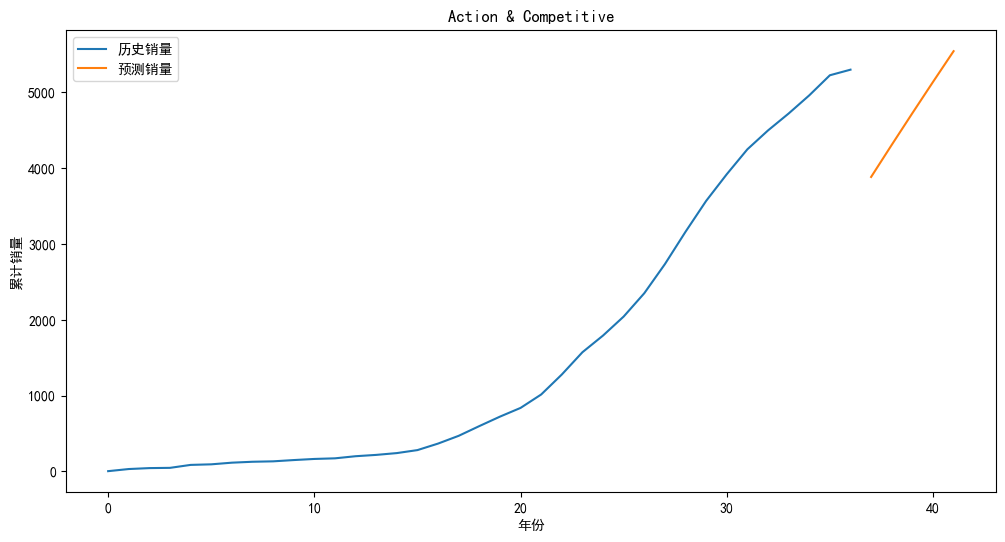

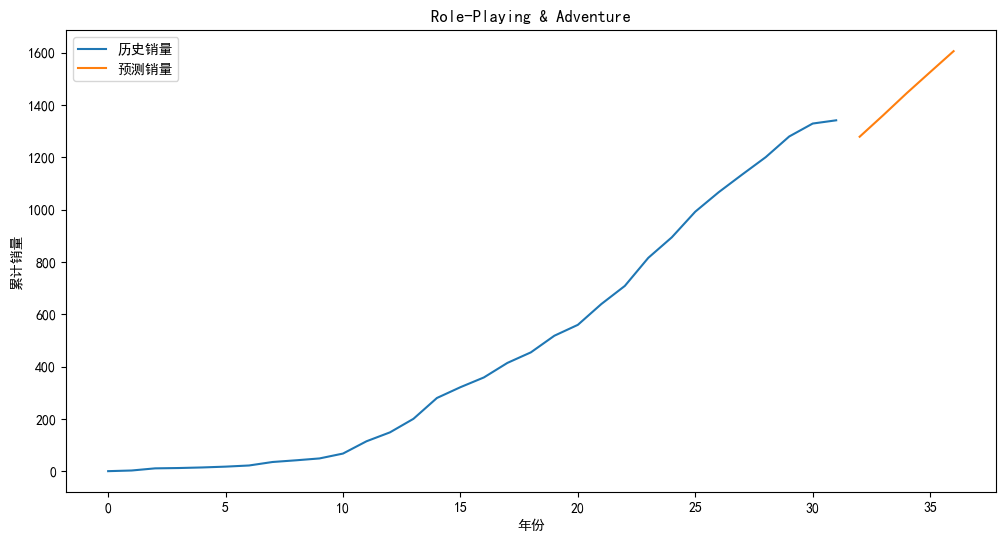

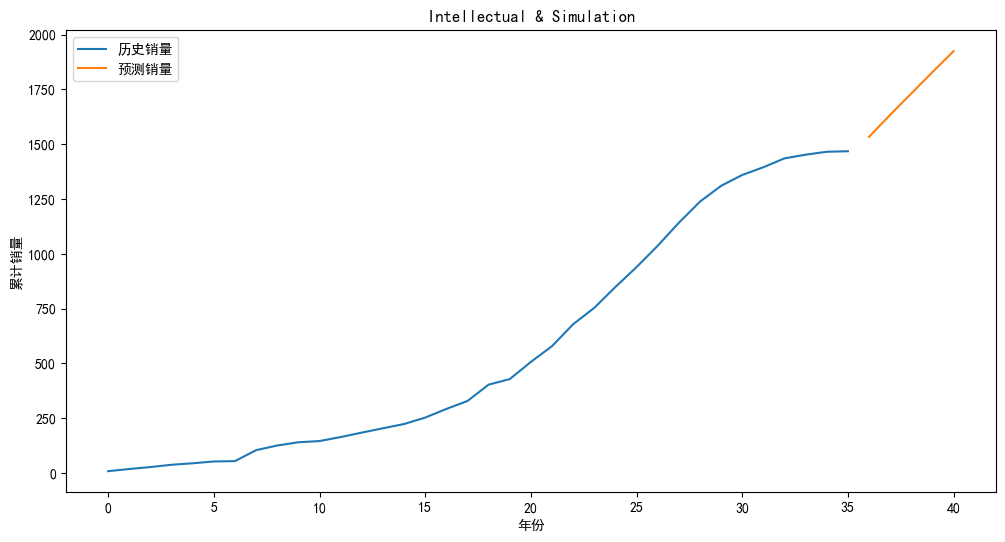

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# 读取数据集
df = pd.read_csv('清洗后的电子游戏销量数据集.csv')

# 定义游戏题材分类字典
game_genres = {
    'Action & Competitive': ['Sports', 'Shooter', 'Racing', 'Fighting', 'Action'],
    'Role-Playing & Adventure': ['Role-Playing', 'Adventure', 'Strategy'],
    'Intellectual & Simulation': ['Puzzle', 'Simulation', 'Platform'],
}

# 初始化分类后的数据集字典
categorized_dfs = {category: pd.DataFrame(columns=df.columns) for category in game_genres.keys()}

# 根据游戏题材分类并排序
for index, row in df.iterrows():
    for category, genres in game_genres.items():
        if row['Genre'] in genres:
            categorized_dfs[category] = pd.concat([categorized_dfs[category], row.to_frame().T])
            break

for category, df in categorized_dfs.items():
    df.sort_values(by='Year', ascending=False, inplace=True)

# 计算每一类游戏截至某年的总销量，结果保留4位小数
cumulative_sales = {}
for category, df in categorized_dfs.items():
    df['Year'] = df['Year'].astype(int)
    years = sorted(df['Year'].unique())
    cumulative_sales[category] = []
    total_sales = 0.0
    for year in years:
        total_sales += df[df['Year'] == year]['Global_Sales'].sum()
        cumulative_sales[category].append(round(total_sales, 4))

# 训练ARIMA模型并进行预测
predictions = {}
for category, sales in cumulative_sales.items():
    # 将销售数据转换为numpy数组
    sales_array = np.array(sales)

    # 划分训练集和测试集
    train_size = int(len(sales_array) * 0.8)
    train, test = sales_array[:train_size], sales_array[train_size:]

    # 寻找最优参数（这里简单使用循环遍历，实际应用中可以使用更复杂的方法）
    best_aic = np.inf
    best_order = None
    for p in range(0, 5):
        for d in range(0, 2):
            for q in range(0, 5):
                try:
                    model = ARIMA(train, order=(p, d, q))
                    results = model.fit()
                    if results.aic < best_aic:
                        best_aic = results.aic
                        best_order = (p, d, q)
                except:
                    continue

    # 使用最优参数训练模型
    model = ARIMA(train, order=best_order)
    results = model.fit()

    # 预测未来5年
    forecast = results.forecast(steps=5)
    forecast_output = []
    for x in forecast:
        forecast_output.append(x + 0.2 * total_sales)
    predictions[category] = forecast_output

    
# 可视化历史值和预测值
for category, sales in cumulative_sales.items():
    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(len(sales)), sales, label='历史销量')
    future_years = np.arange(len(sales), len(sales) + 5)
    plt.plot(future_years, predictions[category], label='预测销量')
    plt.xlabel('年份')
    plt.ylabel('累计销量')
    plt.title(category)
    plt.legend()
    plt.show()